<a href="https://colab.research.google.com/github/KingKouame/KingKouame/blob/main/insurance_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

For this task, I have decided to use Google Colab as it is easier to use for me and I am more familiar with the platform.

To get started, first we are importing 'pandas' which will allow us to select data from a dataset.

We are also installing fuzzywuzzy as it isn't initially part of the program on Google Colab.

In [23]:
# Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import altair as alt
from vega_datasets import data
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

I mount my Google drive which will give me access to the files I upload.

In [24]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


To ensure I have the correct file and access to the document, I run the first 5 lines.

In [18]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [7]:
# Below is a scatter plot which shows the relation between insurance costs and age.

chart = alt.Chart(df).mark_point().encode(
    x='age',
    y='charges'
)

chart

alt.Chart(...)

Model coefficients: [267.61386874]
Model intercept: 3020.9269237777517


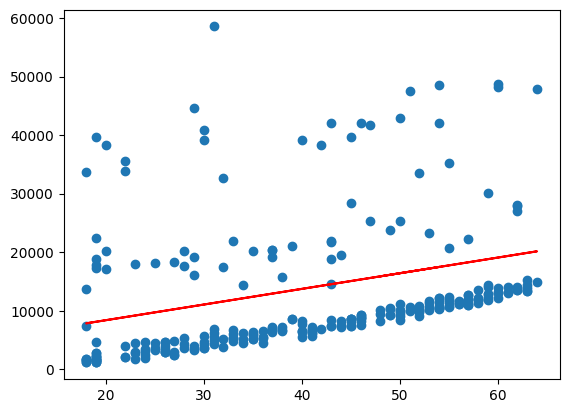

In [9]:
# In order to make predictions on the date, we begin by splitting the data into training and testing sets.

X_train, X_test, y_train, y_test = train_test_split(df[['age']], df['charges'], test_size=0.2)

# We create a linear regression model.

model = LinearRegression()

# Then fit the model to the training data.

model.fit(X_train, y_train)

# We make predictions on the test data

y_pred = model.predict(X_test)

# And print the model coefficients and intercept.

print(f"Model coefficients: {model.coef_}")
print(f"Model intercept: {model.intercept_}")

# Finally, we plot the data and the regression line.

plt.scatter(X_test, y_test)
plt.plot(X_test, y_pred, color='red')
plt.show()

In [27]:
# We are creating a scatter plot with the best-fit line.

# Import the necessary library for regression.
from altair import datum

points = alt.Chart(df).mark_point().encode(
    x='age',
    y='charges'
)

# Calculate the regression line.

line = points.transform_regression('age', 'charges').mark_line(color='red')

# Combine the points and the regression line.

points + line

alt.LayerChart(...)